# SATA Playground Analysis

This notebook analyzes SATA preferred stock dividend payments:
- Fetches current SATA market price
- Calculates months of dividend payments needed to reach current NPV at a configurable discount rate
- Performs sensitivity analysis for dividend rate changes


## Step 1: Setup and Data Fetching


In [36]:
# ============================================================================
# IMPORTS
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json

print("Libraries imported successfully!")


Libraries imported successfully!


In [37]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# Discount rate (annual, will be converted to monthly)
DISCOUNT_RATE_ANNUAL = 0.04153  # 4.8% default

# SATA dividend parameters (hardcoded)
SATA_DIVIDEND_RATE = 0.1225  # 12.25% yield on par value
SATA_PAR_VALUE = 100  # $100 par value
SATA_MONTHLY_DIVIDEND_PER_SHARE = SATA_PAR_VALUE * SATA_DIVIDEND_RATE / 12  # $1.0208 per month

print(f"SATA Dividend Parameters:")
print(f"  Dividend Rate: {SATA_DIVIDEND_RATE:.2%}")
print(f"  Par Value: ${SATA_PAR_VALUE}")
print(f"  Monthly Dividend per Share: ${SATA_MONTHLY_DIVIDEND_PER_SHARE:.4f}")
print(f"  Annual Dividend per Share: ${SATA_PAR_VALUE * SATA_DIVIDEND_RATE:.2f}")
print(f"\nDiscount Rate (Annual): {DISCOUNT_RATE_ANNUAL:.2%}")


SATA Dividend Parameters:
  Dividend Rate: 12.25%
  Par Value: $100
  Monthly Dividend per Share: $1.0208
  Annual Dividend per Share: $12.25

Discount Rate (Annual): 4.15%


In [38]:
# ============================================================================
# DATA FETCHING - Get Current SATA Price
# ============================================================================

def fetch_sata_price():
    """
    Fetch current SATA market price from treasury.strive.com API
    """
    try:
        headers = {
            'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
            'Accept': 'application/json'
        }
        
        api_url = 'https://treasury.strive.com/api/partner-companies?companies=ASST&include_historical=true&include_bitcoin=true&include_market_comparison=false&include_processed_metrics=true&include_partner_info=true'
        
        response = requests.get(api_url, headers=headers, timeout=15)
        
        if response.status_code == 200:
            data = response.json()
            
            # Extract SATA preferred stock price
            companies = data.get('companies', {})
            if 'ASST' in companies:
                asst_data = companies['ASST']
                processed_metrics = asst_data.get('processedMetrics', {})
                preferred_stocks = processed_metrics.get('preferredStocks', [])
                
                if preferred_stocks and len(preferred_stocks) > 0:
                    sata = preferred_stocks[0]
                    price = sata.get('price', 0)
                    
                    if price > 0:
                        print(f"✓ Successfully fetched SATA price: ${price:.2f}")
                        return float(price)
                    else:
                        print(f"⚠ SATA price not available in API response")
                        return None
                else:
                    print(f"⚠ SATA preferred stock not found in API response")
                    return None
            else:
                print(f"⚠ ASST not found in API response")
                return None
        else:
            print(f"✗ API returned status {response.status_code}")
            return None
            
    except Exception as e:
        print(f"✗ Error fetching SATA price: {e}")
        return None

# Fetch current price
SATA_CURRENT_PRICE = fetch_sata_price()

if SATA_CURRENT_PRICE is None:
    print("\n⚠ Using fallback price. Update manually if needed.")
    SATA_CURRENT_PRICE = 91.51  # Fallback


✓ Successfully fetched SATA price: $91.51


## Step 2: NPV Calculation Functions


In [39]:
# ============================================================================
# NPV CALCULATION FUNCTIONS
# ============================================================================

def calculate_monthly_discount_rate(annual_rate):
    """
    Convert annual discount rate to monthly rate
    """
    return (1 + annual_rate) ** (1/12) - 1

def calculate_npv_monthly_payments(monthly_payment, annual_discount_rate, num_months):
    """
    Calculate NPV of monthly payments
    
    Parameters:
    -----------
    monthly_payment : float
        Monthly dividend payment per share
    annual_discount_rate : float
        Annual discount rate (e.g., 0.048 for 4.8%)
    num_months : int
        Number of months of payments
    
    Returns:
    --------
    float
        Net Present Value of the monthly payments
    """
    monthly_rate = calculate_monthly_discount_rate(annual_discount_rate)
    
    # Calculate NPV: sum of monthly_payment / (1 + monthly_rate)^n for n = 1 to num_months
    npv = 0.0
    for n in range(1, num_months + 1):
        npv += monthly_payment / ((1 + monthly_rate) ** n)
    
    return npv

# Test the function
monthly_rate = calculate_monthly_discount_rate(DISCOUNT_RATE_ANNUAL)
print(f"Monthly discount rate: {monthly_rate:.6f} ({monthly_rate*100:.4f}%)")
print(f"\nTest: NPV of 12 months of ${SATA_MONTHLY_DIVIDEND_PER_SHARE:.4f} payments:")
test_npv = calculate_npv_monthly_payments(SATA_MONTHLY_DIVIDEND_PER_SHARE, DISCOUNT_RATE_ANNUAL, 12)
print(f"  ${test_npv:.2f}")


Monthly discount rate: 0.003397 (0.3397%)

Test: NPV of 12 months of $1.0208 payments:
  $11.98


## Step 3: Find Months to Reach Current Price


In [40]:
# ============================================================================
# FIND MONTHS NEEDED TO REACH CURRENT PRICE
# ============================================================================

def find_months_to_price(monthly_payment, annual_discount_rate, target_price, max_months=10000):
    """
    Find the number of months where NPV equals target price
    
    Parameters:
    -----------
    monthly_payment : float
        Monthly dividend payment per share
    annual_discount_rate : float
        Annual discount rate
    target_price : float
        Target price (current market price)
    max_months : int
        Maximum number of months to search (default: 10000)
    
    Returns:
    --------
    int
        Number of months needed, or None if not found within max_months
    """
    # Binary search for efficiency
    low = 1
    high = max_months
    
    while low <= high:
        mid = (low + high) // 2
        npv = calculate_npv_monthly_payments(monthly_payment, annual_discount_rate, mid)
        
        if abs(npv - target_price) < 0.01:  # Within 1 cent
            return mid
        elif npv < target_price:
            low = mid + 1
        else:
            high = mid - 1
    
    # If exact match not found, return the closest
    # Check both low and high
    npv_low = calculate_npv_monthly_payments(monthly_payment, annual_discount_rate, low)
    npv_high = calculate_npv_monthly_payments(monthly_payment, annual_discount_rate, high)
    
    if abs(npv_low - target_price) < abs(npv_high - target_price):
        return low
    else:
        return high

# Calculate months needed
months_needed = find_months_to_price(
    SATA_MONTHLY_DIVIDEND_PER_SHARE,
    DISCOUNT_RATE_ANNUAL,
    SATA_CURRENT_PRICE
)

# Calculate NPV and totals
npv_at_months = calculate_npv_monthly_payments(
    SATA_MONTHLY_DIVIDEND_PER_SHARE,
    DISCOUNT_RATE_ANNUAL,
    months_needed
)

total_undiscounted = SATA_MONTHLY_DIVIDEND_PER_SHARE * months_needed

# Display results
print("=" * 70)
print("MONTHS TO REACH CURRENT PRICE")
print("=" * 70)
print(f"Current SATA Price: ${SATA_CURRENT_PRICE:.2f}")
print(f"Monthly Dividend per Share: ${SATA_MONTHLY_DIVIDEND_PER_SHARE:.4f}")
print(f"Discount Rate (Annual): {DISCOUNT_RATE_ANNUAL:.2%}")
print(f"Discount Rate (Monthly): {calculate_monthly_discount_rate(DISCOUNT_RATE_ANNUAL):.6f} ({calculate_monthly_discount_rate(DISCOUNT_RATE_ANNUAL)*100:.4f}%)")
print(f"\nMonths Needed: {months_needed:,}")
print(f"Years Needed: {months_needed / 12:.2f}")
print(f"\nNPV at {months_needed:,} months: ${npv_at_months:.2f}")
print(f"Total Undiscounted Payments: ${total_undiscounted:.2f}")
print(f"Difference (Undiscounted - NPV): ${total_undiscounted - npv_at_months:.2f}")
print("=" * 70)


MONTHS TO REACH CURRENT PRICE
Current SATA Price: $91.51
Monthly Dividend per Share: $1.0208
Discount Rate (Annual): 4.15%
Discount Rate (Monthly): 0.003397 (0.3397%)

Months Needed: 107
Years Needed: 8.92

NPV at 107 months: $91.45
Total Undiscounted Payments: $109.23
Difference (Undiscounted - NPV): $17.78


## Step 4: Sensitivity Analysis


In [41]:
# ============================================================================
# SENSITIVITY ANALYSIS - Dividend Rate Changes
# ============================================================================

def sensitivity_analysis(base_dividend_rate, target_price, annual_discount_rate, 
                         min_change=-0.005, max_change=0.005, step=0.0025):
    """
    Perform sensitivity analysis for dividend rate changes
    
    Parameters:
    -----------
    base_dividend_rate : float
        Base dividend rate (e.g., 0.1225 for 12.25%)
    target_price : float
        Target price (current market price)
    annual_discount_rate : float
        Annual discount rate
    min_change : float
        Minimum change in dividend rate (default: -0.5%)
    max_change : float
        Maximum change in dividend rate (default: +0.5%)
    step : float
        Step size for changes (default: 0.25%)
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame with columns: dividend_rate, monthly_dividend, months_needed, change_from_baseline
    """
    results = []
    
    # Generate dividend rate changes
    changes = np.arange(min_change, max_change + step/2, step)
    
    # Calculate baseline months (keep constant for all scenarios)
    base_monthly_dividend = SATA_PAR_VALUE * base_dividend_rate / 12
    baseline_months = find_months_to_price(base_monthly_dividend, annual_discount_rate, target_price)
    
    # Calculate baseline NPV for reference
    baseline_npv = calculate_npv_monthly_payments(base_monthly_dividend, annual_discount_rate, baseline_months)
    
    for change in changes:
        dividend_rate = base_dividend_rate + change
        monthly_dividend = SATA_PAR_VALUE * dividend_rate / 12
        
        # Calculate NPV at constant baseline months (not recalculating months)
        npv = calculate_npv_monthly_payments(monthly_dividend, annual_discount_rate, baseline_months)
        
        results.append({
            'dividend_rate': dividend_rate,
            'dividend_rate_pct': dividend_rate * 100,
            'monthly_dividend': monthly_dividend,
            'months': baseline_months,  # Constant months
            'years': baseline_months / 12,
            'npv': npv,
            'npv_change_from_baseline': npv - baseline_npv,
            'change_pct': change * 100
        })
    
    return pd.DataFrame(results)

# Run sensitivity analysis
sensitivity_df = sensitivity_analysis(
    SATA_DIVIDEND_RATE,
    SATA_CURRENT_PRICE,
    DISCOUNT_RATE_ANNUAL,
    min_change=-0.005,  # -0.5%
    max_change=0.005,  # +0.5%
    step=0.0025  # 0.25% increments
)

print("SENSITIVITY ANALYSIS RESULTS")
print("=" * 70)
print(sensitivity_df.to_string(index=False))
print("=" * 70)


SENSITIVITY ANALYSIS RESULTS
 dividend_rate  dividend_rate_pct  monthly_dividend  months    years       npv  npv_change_from_baseline  change_pct
        0.1175              11.75          0.979167     107 8.916667 87.719614                 -3.732750       -0.50
        0.1200              12.00          1.000000     107 8.916667 89.585989                 -1.866375       -0.25
        0.1225              12.25          1.020833     107 8.916667 91.452364                  0.000000        0.00
        0.1250              12.50          1.041667     107 8.916667 93.318738                  1.866375        0.25
        0.1275              12.75          1.062500     107 8.916667 95.185113                  3.732750        0.50


## Step 5: Visualizations


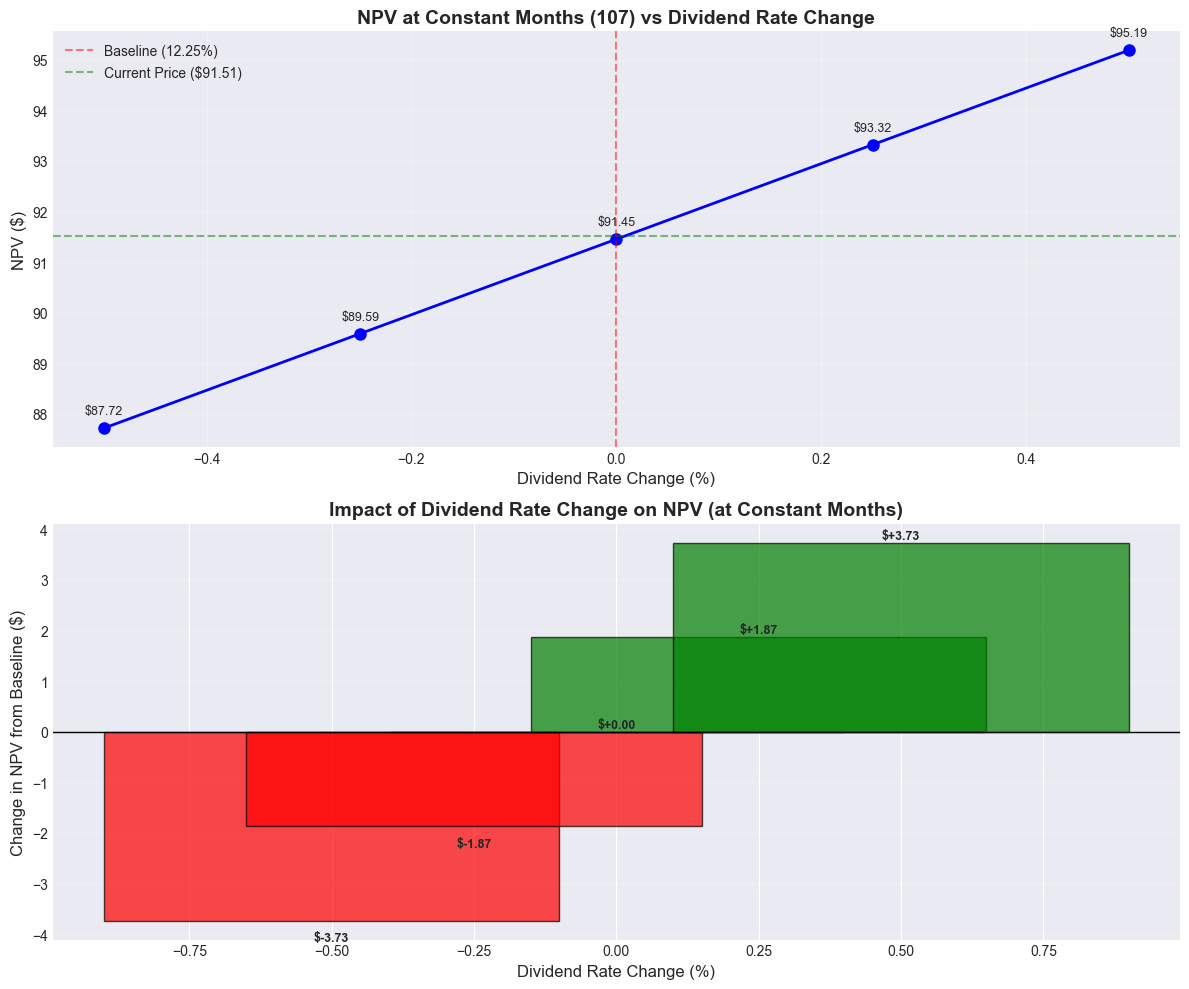


DETAILED SENSITIVITY ANALYSIS TABLE
Dividend Rate (%) Monthly Dividend ($)  Months (constant)    Years NPV ($) NPV Change from Baseline ($)
           11.75%              $0.9792                107 8.916667  $87.72                       $-3.73
           12.00%              $1.0000                107 8.916667  $89.59                       $-1.87
           12.25%              $1.0208                107 8.916667  $91.45                       $+0.00
           12.50%              $1.0417                107 8.916667  $93.32                       $+1.87
           12.75%              $1.0625                107 8.916667  $95.19                       $+3.73


In [42]:
# ============================================================================
# VISUALIZATIONS
# ============================================================================

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create figure with subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: NPV vs Dividend rate change (at constant months)
ax1 = axes[0]
ax1.plot(sensitivity_df['change_pct'], sensitivity_df['npv'], 
         marker='o', linewidth=2, markersize=8, color='blue')
ax1.axvline(x=0, color='r', linestyle='--', alpha=0.5, label='Baseline (12.25%)')
ax1.axhline(y=SATA_CURRENT_PRICE, color='g', linestyle='--', alpha=0.5, label=f'Current Price (${SATA_CURRENT_PRICE:.2f})')
ax1.set_xlabel('Dividend Rate Change (%)', fontsize=12)
ax1.set_ylabel('NPV ($)', fontsize=12)
ax1.set_title(f'NPV at Constant Months ({int(sensitivity_df.iloc[0]["months"])}) vs Dividend Rate Change', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Add value labels
for _, row in sensitivity_df.iterrows():
    ax1.annotate(f"${row['npv']:.2f}", 
                (row['change_pct'], row['npv']),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

# Plot 2: Change in NPV from baseline
ax2 = axes[1]
colors = ['red' if x < 0 else 'green' if x > 0 else 'blue' for x in sensitivity_df['npv_change_from_baseline']]
ax2.bar(sensitivity_df['change_pct'], sensitivity_df['npv_change_from_baseline'], 
        color=colors, alpha=0.7, edgecolor='black', linewidth=1)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Dividend Rate Change (%)', fontsize=12)
ax2.set_ylabel('Change in NPV from Baseline ($)', fontsize=12)
ax2.set_title('Impact of Dividend Rate Change on NPV (at Constant Months)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for _, row in sensitivity_df.iterrows():
    height = row['npv_change_from_baseline']
    ax2.annotate(f"${height:+.2f}", 
                (row['change_pct'], height),
                textcoords="offset points", xytext=(0,3 if height >= 0 else -15), 
                ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Create detailed table visualization
print("\n" + "=" * 70)
print("DETAILED SENSITIVITY ANALYSIS TABLE")
print("=" * 70)

# Format the table nicely
display_df = sensitivity_df[['dividend_rate_pct', 'monthly_dividend', 'months', 'years', 'npv', 'npv_change_from_baseline']].copy()
display_df.columns = ['Dividend Rate (%)', 'Monthly Dividend ($)', 'Months (constant)', 'Years', 'NPV ($)', 'NPV Change from Baseline ($)']
display_df['Monthly Dividend ($)'] = display_df['Monthly Dividend ($)'].apply(lambda x: f"${x:.4f}")
display_df['Dividend Rate (%)'] = display_df['Dividend Rate (%)'].apply(lambda x: f"{x:.2f}%")
display_df['NPV ($)'] = display_df['NPV ($)'].apply(lambda x: f"${x:.2f}")
display_df['NPV Change from Baseline ($)'] = display_df['NPV Change from Baseline ($)'].apply(lambda x: f"${x:+.2f}")

print(display_df.to_string(index=False))
print("=" * 70)


## Summary

This analysis shows:
- How many months of dividend payments are needed to reach the current SATA price at the given discount rate
- The sensitivity of this calculation to changes in the dividend rate
- Visual representations of the relationship between dividend rate and months needed
